In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
from tensorflow.keras.utils import set_random_seed

set_random_seed(0)

# input
input = Input(shape =(28,28,1))

# 1st Conv Block
x = Conv2D (filters =4, kernel_size =3, padding ='same', activation='relu')(input)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


# 2nd Conv Block
x = Conv2D (filters =8, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


x = Flatten()(x)
x = Dense(units = 16, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 4)         40        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 4)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 8)         296       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 8)          0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 392)               0     

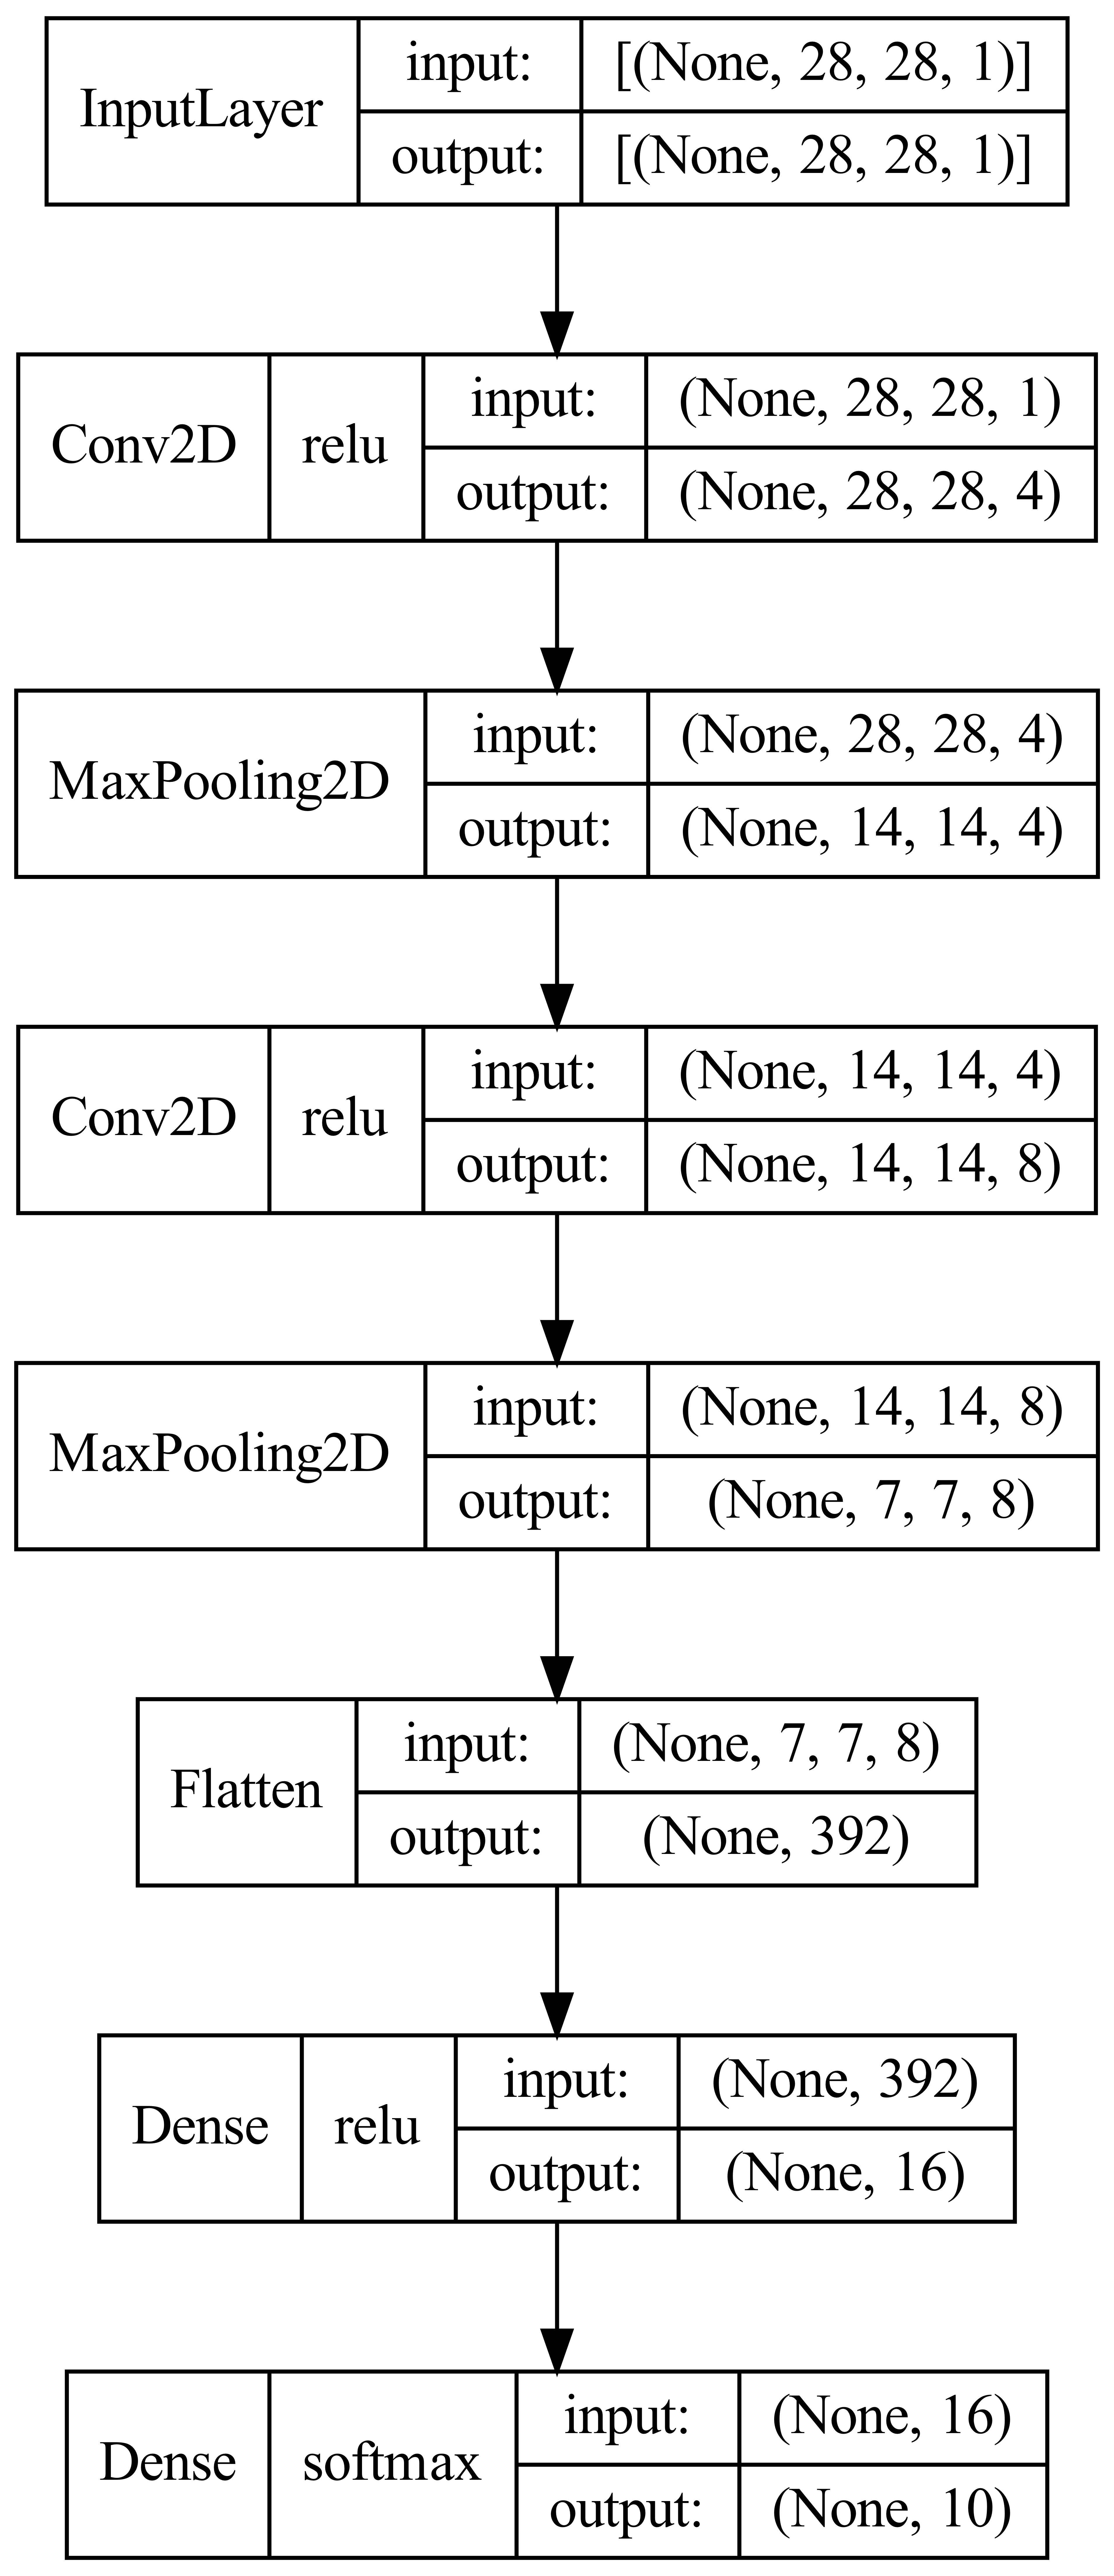

In [3]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file="experiments/exp8/model.png", show_shapes=True, show_layer_names = False, dpi=1000, show_layer_activations=True, expand_nested=True)

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [6]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=8,
)

Fit model on training data
Epoch 1/8
938/938 [==============================] - 7s 7ms/step - loss: 0.9125 - sparse_categorical_accuracy: 0.7638
Epoch 2/8
938/938 [==============================] - 7s 7ms/step - loss: 0.1857 - sparse_categorical_accuracy: 0.9474
Epoch 3/8
938/938 [==============================] - 7s 8ms/step - loss: 0.1205 - sparse_categorical_accuracy: 0.9641
Epoch 4/8
938/938 [==============================] - 7s 7ms/step - loss: 0.0942 - sparse_categorical_accuracy: 0.9718
Epoch 5/8
938/938 [==============================] - 7s 7ms/step - loss: 0.0797 - sparse_categorical_accuracy: 0.9761
Epoch 6/8
938/938 [==============================] - 7s 8ms/step - loss: 0.0706 - sparse_categorical_accuracy: 0.9784
Epoch 7/8
938/938 [==============================] - 7s 7ms/step - loss: 0.0648 - sparse_categorical_accuracy: 0.9801
Epoch 8/8
938/938 [==============================] - 7s 7ms/step - loss: 0.0606 - sparse_categorical_accuracy: 0.9814


In [7]:
print("Evaluate on test data")
results = model.evaluate(x_test, y_test)

Evaluate on test data
313/313 [==============================] - 1s 2ms/step - loss: 0.0675 - sparse_categorical_accuracy: 0.9795


In [6]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=5,
)

Fit model on training data
Epoch 1/5
938/938 [==============================] - 7s 7ms/step - loss: 0.9125 - sparse_categorical_accuracy: 0.7638
Epoch 2/5
938/938 [==============================] - 7s 7ms/step - loss: 0.1857 - sparse_categorical_accuracy: 0.9474
Epoch 3/5
938/938 [==============================] - 6s 7ms/step - loss: 0.1205 - sparse_categorical_accuracy: 0.9641
Epoch 4/5
938/938 [==============================] - 7s 7ms/step - loss: 0.0942 - sparse_categorical_accuracy: 0.9718
Epoch 5/5
938/938 [==============================] - 7s 7ms/step - loss: 0.0797 - sparse_categorical_accuracy: 0.9761


In [7]:
print("Evaluate on test data")
results = model.evaluate(x_test, y_test)

Evaluate on test data
313/313 [==============================] - 1s 2ms/step - loss: 0.0944 - sparse_categorical_accuracy: 0.9725


In [8]:
model.save("experiments/exp8/model/")

INFO:tensorflow:Assets written to: experiments/exp8/model/assets


INFO:tensorflow:Assets written to: experiments/exp8/model/assets


In [9]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 1s 2ms/step
matched numbers : 9795
non matched numbers : 205


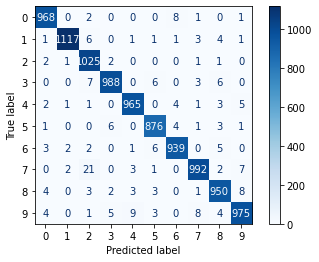

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("experiments/exp8/confusion_matrix.svg", dpi=1000)
plt.show()

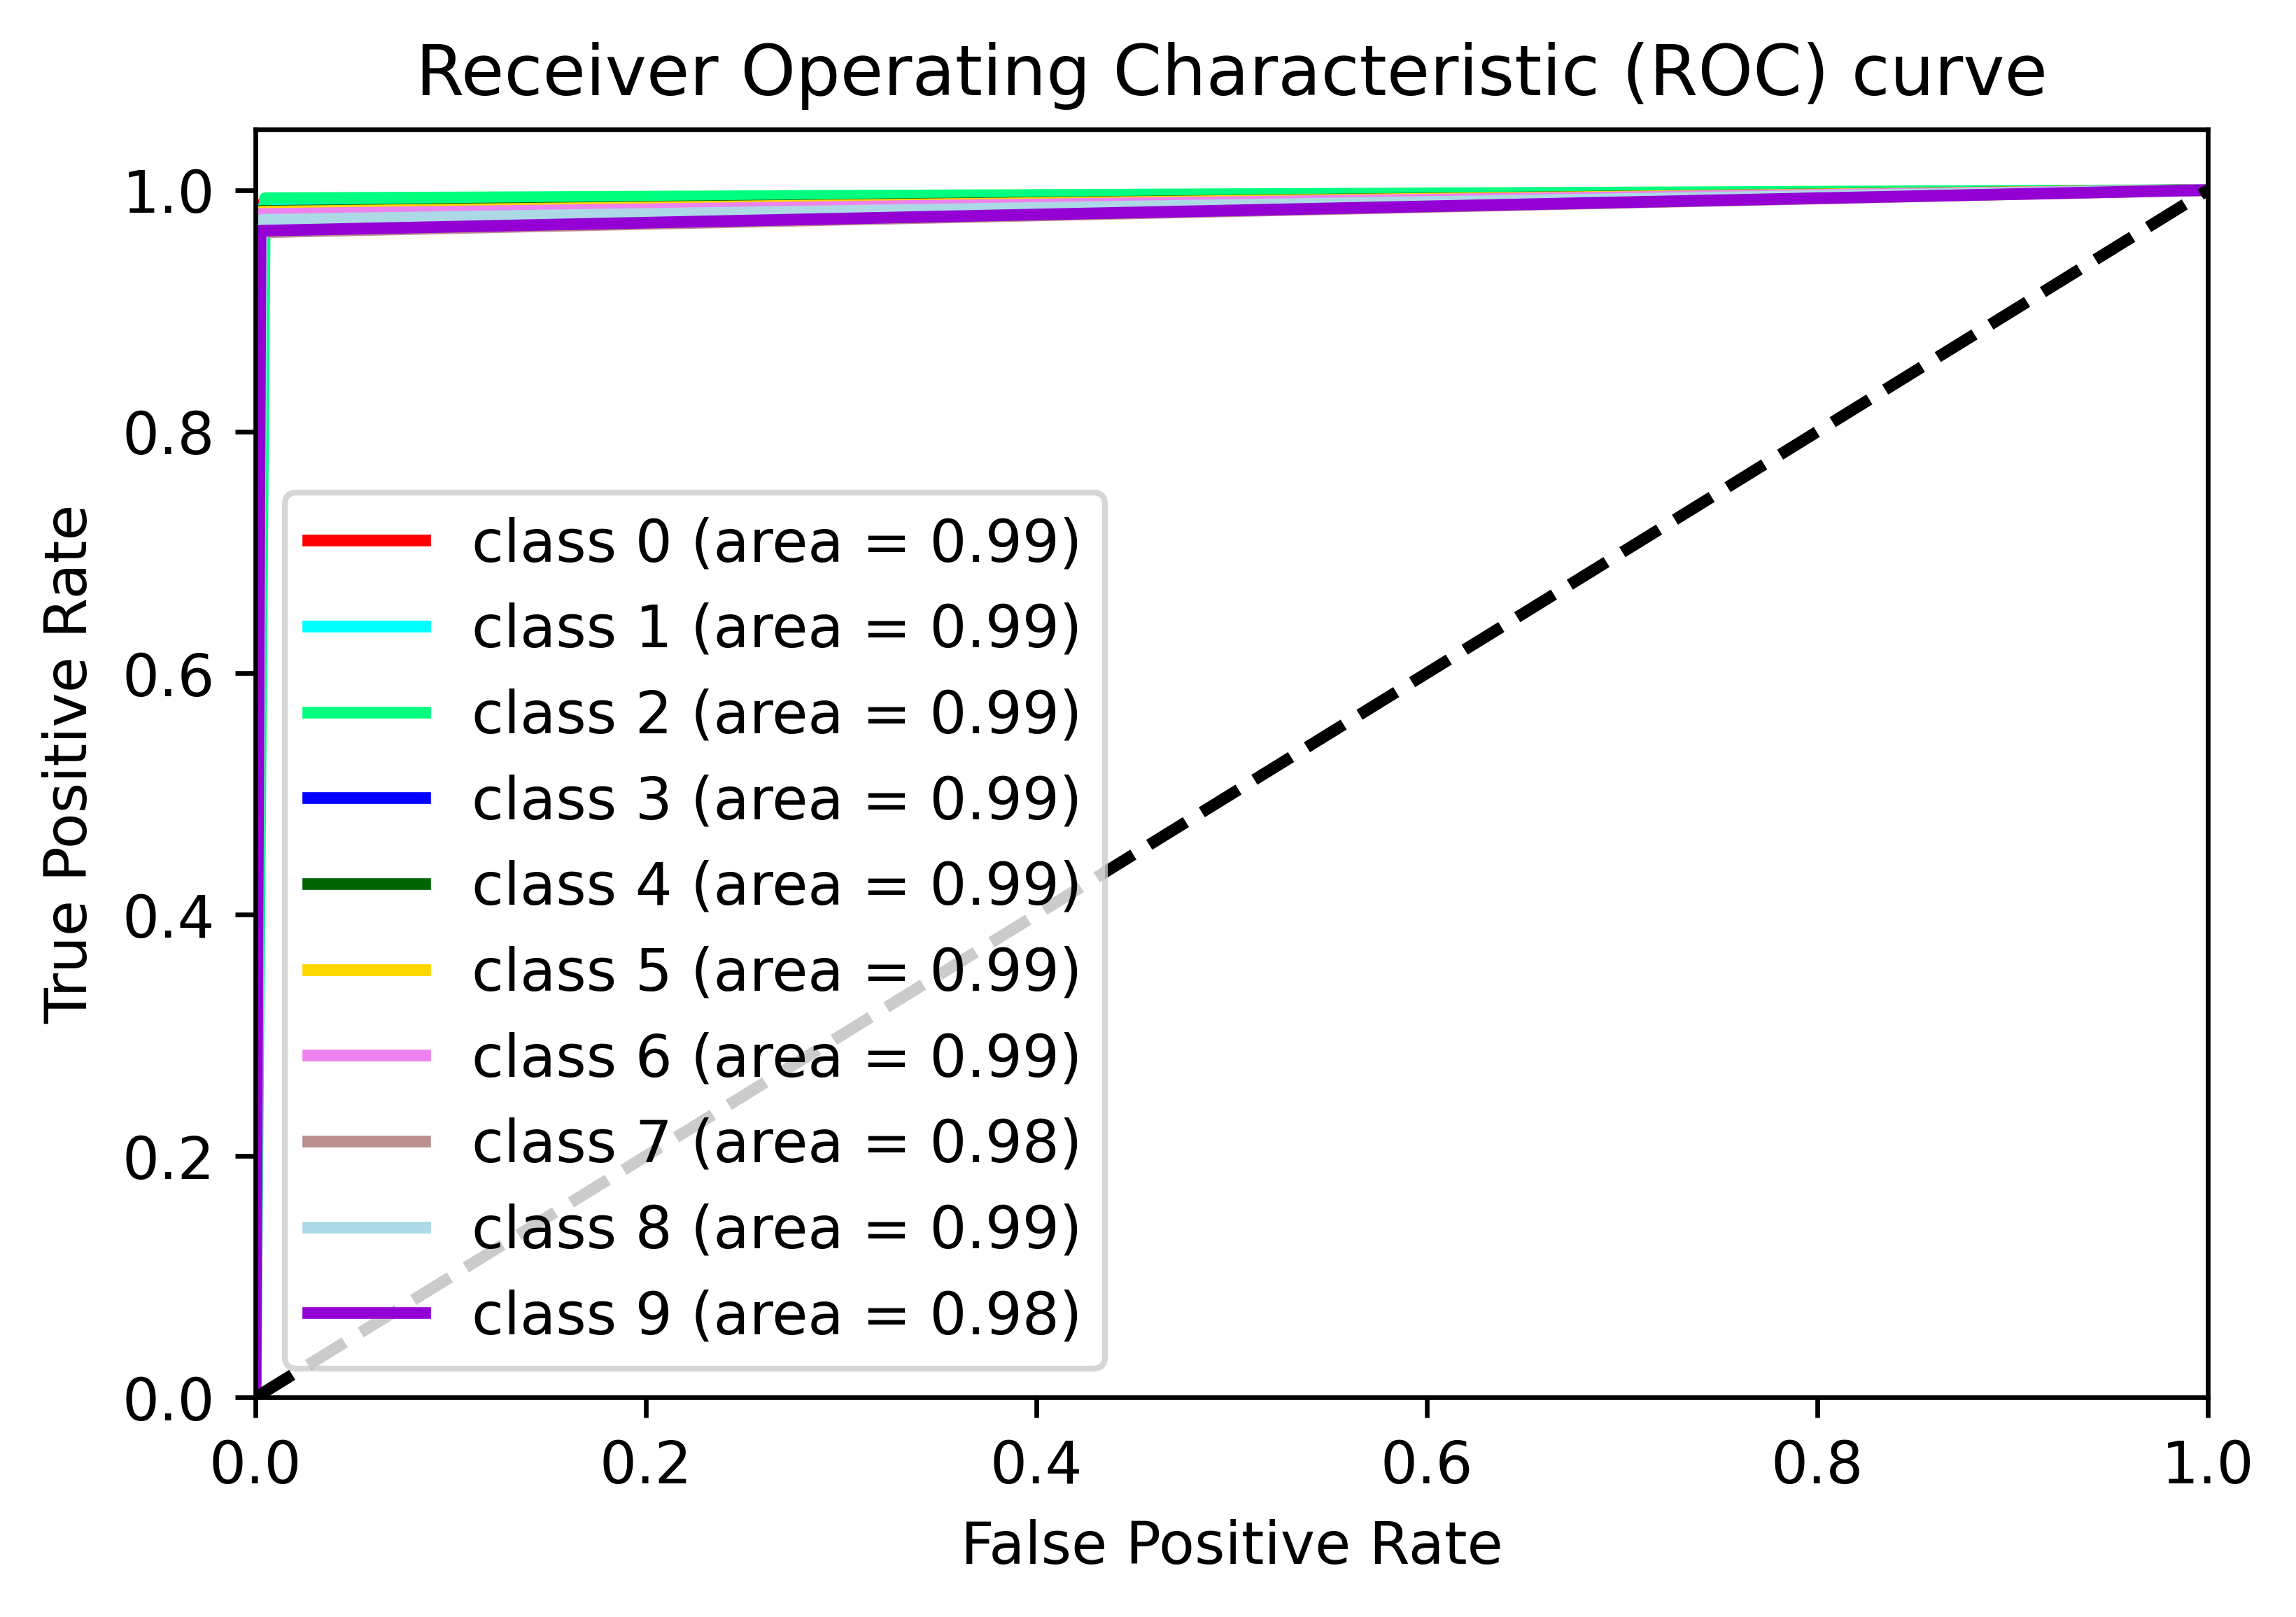

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])


# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2




colors = cycle(["red", "cyan", "springgreen", "blue", "darkgreen", "gold", "violet", "rosybrown", "lightblue", "darkviolet"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"class {i} (area = {roc_auc[i]:0.2f})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.legend()
plt.savefig("experiments/exp4/ROC.jpg", bbox_inches="tight", dpi=1000)

In [13]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [14]:
f1_score(y_test, y_pred, average=None)

array([0.98524173, 0.98937112, 0.97619048, 0.98161947, 0.98268839,
       0.97986577, 0.98119122, 0.97302599, 0.97336066, 0.9715994 ])

In [15]:
precision_score(y_test, y_pred, average=None)

array([0.98274112, 0.99465717, 0.95973783, 0.98504487, 0.98268839,
       0.97767857, 0.98221757, 0.98120673, 0.97137014, 0.97695391])

In [16]:
recall_score(y_test, y_pred, average=None)

array([0.9877551 , 0.98414097, 0.99321705, 0.97821782, 0.98268839,
       0.98206278, 0.98016701, 0.96498054, 0.97535934, 0.96630327])

In [17]:
accuracy_score(y_test, y_pred)

0.9795